## 🏠 California House Price Prediction

📌 **Project Overview**

This project aims to predict the median house value in California districts using various demographic and geographic features. By leveraging machine learning, we can identify which factors (like median income or location) most heavily influence property costs.

**kaggle link:** https://www.kaggle.com/datasets/camnugent/california-housing-prices


**📊 Key Performance Metrics**

- To evaluate the accuracy of the model, I focused on two primary metrics:

**R2 Score:** 0.835

- This tells us how much of the price variation the model actually understands.

**RMSE (Root Mean Square Error):** 0.231

- This represents the average dollar amount our predictions are off by.

**🛠️ The Pipeline**

**Exploratory Data Analysis (EDA):** 

- Visualizing correlations and geographical heatmaps.

**Data Preprocessing:** 

- Handling missing values and scaling numerical data.

**Modeling:** 

- Implementing [Linear Regression(Basline Model), Ridge, Lasso, Random Forest & HistGradientBoosting] for best results.

**Conclusion:**

💻 Tech Stack
Python | Pandas | Scikit-Learn | Matplotlib | Seaborn

#### Step 1: Import Libraries 

In [53]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error,  r2_score

#### Step 2:  Configurations

In [54]:
# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

# Configure Matplotlib for better visualization
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

# Configurations and Constants
RANDOM_STATE = 42
CSV_PATH = "dataset/housing.csv"  # Updated for Kaggle
TARGET_COL = "median_house_value"                                 # Target variable for prediction

#### Step 3: Load the Data

In [55]:
# Load the Data
df = pd.read_csv(CSV_PATH)

In [56]:
# Let's check the shape of the dataset
df.shape

(20640, 10)

In [57]:
# Let's check the first few rows of the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


### Step 4: Exploratory Data Analysis (EDA)

In [58]:
# Let's view the column names 
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**About this file**

The dataset contains information about various features of houses in California, along with their corresponding median house values. The features include:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

In [59]:
# Let's take a glance on data info
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


* There are 20640 entries(rows) and 10 variables(columns) in the house dataset.
* All the features are numerical except for oceanProximity which is categorical.

In [60]:
# Let's have a look on numerical and categorical features separately
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Target Column: {TARGET_COL}")
print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Target Column: median_house_value
Numerical Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical Columns: ['ocean_proximity']


In [61]:
# Let's check the data for missing values
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [62]:
# Checking the presence of any missing values in each column by for loop
for col in df.columns:
    print(f"Column: {col}")
    value_counts = df[col].value_counts()
    missing_count = df[col].isnull().sum()
    
    print("Most common values:")
    print(value_counts.head())
    print(f"Missing values: {missing_count}\n")

Column: longitude
Most common values:
longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
Name: count, dtype: int64
Missing values: 0

Column: latitude
Most common values:
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
Name: count, dtype: int64
Missing values: 0

Column: housing_median_age
Most common values:
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
Name: count, dtype: int64
Missing values: 0

Column: total_rooms
Most common values:
total_rooms
1527.000    18
1613.000    17
1582.000    17
2127.000    16
1717.000    15
Name: count, dtype: int64
Missing values: 0

Column: total_bedrooms
Most common values:
total_bedrooms
280.000    55
331.000    51
345.000    50
343.000    49
393.000    49
Name: count, dtype: int64
Missing values: 207

Column: population
Most common values:
population
891.000     25
761.000     24
1227.000    24
1052.000    24
850.000     24
Name: co

In [63]:
# Check the data for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate values: {duplicate_count}")

# # Drop duplicate if any
# df = df.drop_duplicates()
# print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate values: 0


In [64]:
# Let's check the statistical summary of the data (Desccriptive statistics)
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [65]:
# Let's check the statistical summary of the data (Desccriptive statistics) with better visualization by transposing the result and applying background gradient
df[num_cols].describe().T.style.background_gradient(cmap='Blues').format("{:.3f}")

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


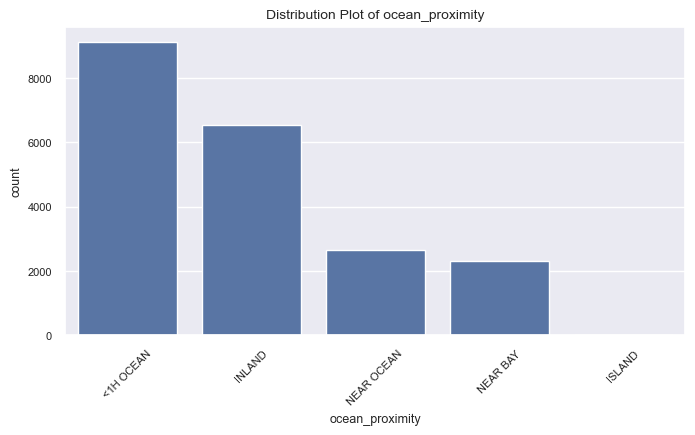

--------------------------------------------------------------------------------
Value counts for ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
--------------------------------------------------------------------------------


In [66]:
# Count plot for categorical features
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

print("-" * 80)

# Value counts for categorical features
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 80)

# As there is only one categorical feature, So one plot has generated. for loop is used to handle multiple categorical features if present in the dataset (in future if we use different dataset with multiple categorical features)

📈 **Let's have a look on Target Variable Distribution Plot**

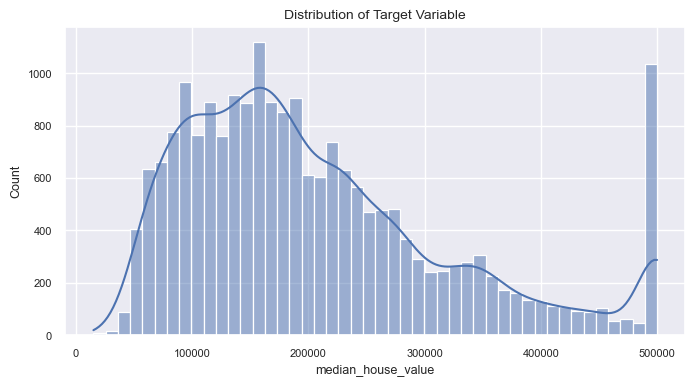

In [67]:
# Target variable distribution
plt.figure(figsize=(8,4))
sns.histplot(df[TARGET_COL], kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel(TARGET_COL)
plt.show()

In [68]:
# Value counts for the target variable
print('-' * 80)
print(df[TARGET_COL].value_counts())
print('-' * 80)

# Higher cap value, in the presence of higher cap value, our r2 will be lower, because the model will not be able to capture the variance in the data. On the other hand, if we set a lower cap value, we may lose some important information about the data, which can also lead to a lower r2 score. 

--------------------------------------------------------------------------------
median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
359200.000      1
54900.000       1
377600.000      1
81200.000       1
47000.000       1
Name: count, Length: 3842, dtype: int64
--------------------------------------------------------------------------------


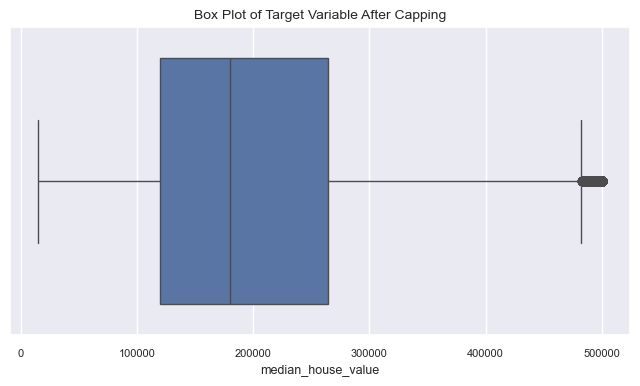

In [69]:
# Box plot to visualize the effect of capping on the target variable
plt.figure(figsize=(8,4))
sns.boxplot(x=df[TARGET_COL])
plt.title("Box Plot of Target Variable After Capping")
plt.show()

📈 **Let's check other distributions**

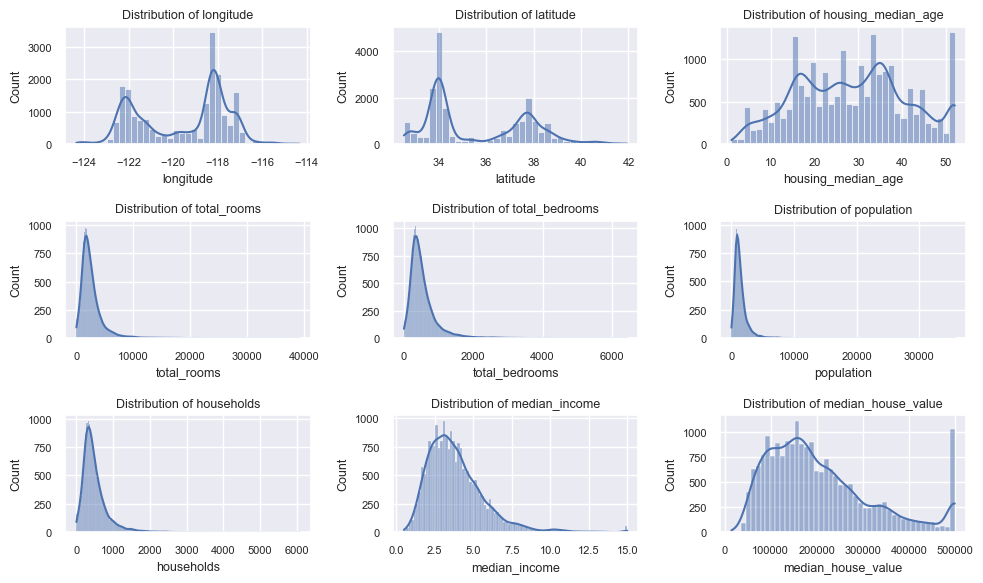

In [70]:
# Let's check the distribution of the other variables in the form of subplots
fig, axes = plt.subplots(3,3, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}", fontsize=9)
        axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

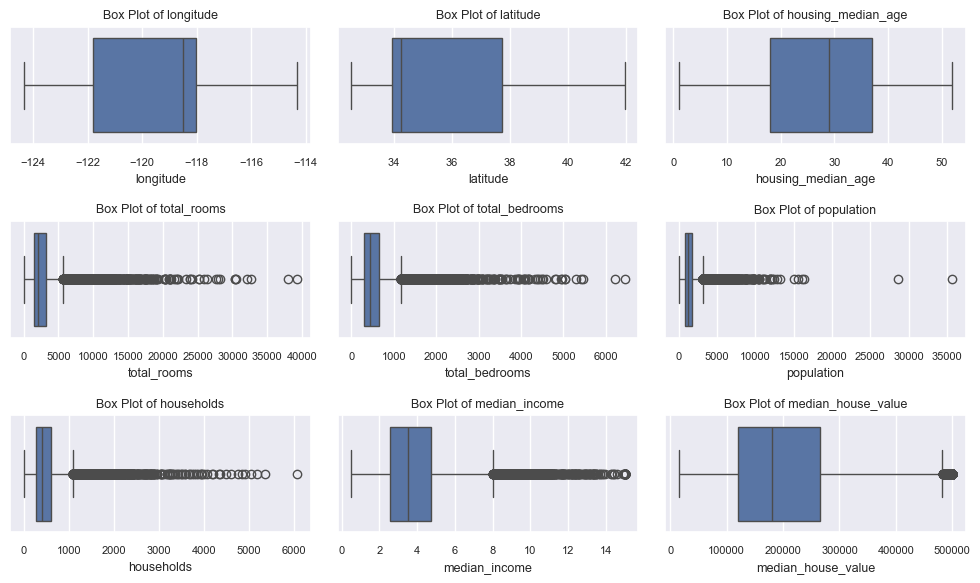

In [71]:
# Outliers analysis using box plots for numerical features
fig, axes = plt.subplots(3,3, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Box Plot of {col}", fontsize=9)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Note:**

 We will keep these outliers as they are because they are not errors but they are just extreme values. They may be real or actual values and they can provide valuable information to the model. Removing them might lead to loss of important information and can negatively impact the model's performance. Instead, we can consider using techniques like log transformation or robust scaling to handle the outliers without removing them from the dataset.

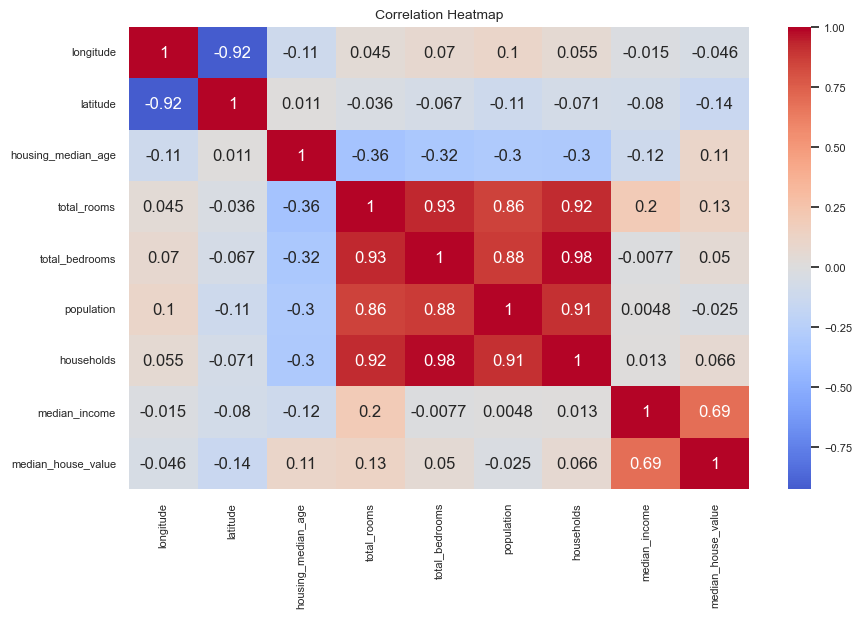

In [72]:
# Correlation heatmap to visualize the highly correlated columns 
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [73]:
# Correlation of the features with the target variable
correlation_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation of features with the target variable:")
print(correlation_with_target)

Correlation of features with the target variable:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


---

#### Key Insights from EDA:
1. Dataset has 9 numerical features and one categorical feature (oceanProximity).
2. There are 207 missing values in the totalBedrooms column. 
3. The target variable (median_house_value) is right-skewed, indicating that most houses have lower values, with a few high-value outliers.
4. The features totalRooms, totalBedrooms, population, and households also show right-skewed distributions, suggesting the presence of outliers.
5. The correlation heatmap reveals that medianIncome has the strongest positive correlation with medianHouseValue, while totalRooms and totalBedrooms also show positive correlations. Longitude and latitude have weaker correlations with the target variable.

---

#### Step 5: Data Preprocessing & Evaluation
- Imputation of missing values by median
- Encoding of categorical features using one-hot encoding
- Feature scaling for numerical features(for linear model) using StandardScaler
- Pipeline creation for data preprocessing to avoid data leakage and model training
- Baseline model building (Linear Regression), CV(model selection) and hyperparameter tuning (Random Forest, Gradient Boosting)
- Model evaluation metrics (RMSE as a primary metrics, MAE & R² as secondary metrics)
- Final evaluation only on the test set using the best model obtained from CV and hyperparameter tuning.

---

**Data Preprocessing**

In [74]:
# Log transformation of the target variable to handle skewness
df[TARGET_COL] = np.log1p(df[TARGET_COL])

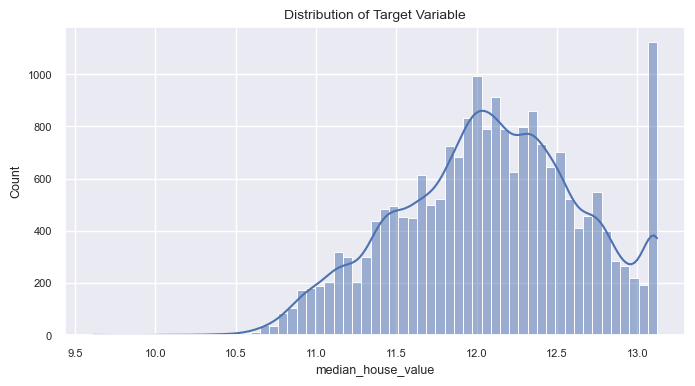

In [75]:
# Target variable distribution
plt.figure(figsize=(8,4))
sns.histplot(df[TARGET_COL], kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel(TARGET_COL)
plt.show()

In [76]:
# Separating features and target variable
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [77]:
# Check the first few rows of the features and target variable
print("Features (X):")
print(X.head())
print("-" * 80)
print("\nTarget variable (y):")
print(y.head())

Features (X):
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   -122.230    37.880              41.000      880.000         129.000   
1   -122.220    37.860              21.000     7099.000        1106.000   
2   -122.240    37.850              52.000     1467.000         190.000   
3   -122.250    37.850              52.000     1274.000         235.000   
4   -122.250    37.850              52.000     1627.000         280.000   

   population  households  median_income ocean_proximity  
0     322.000     126.000          8.325        NEAR BAY  
1    2401.000    1138.000          8.301        NEAR BAY  
2     496.000     177.000          7.257        NEAR BAY  
3     558.000     219.000          5.643        NEAR BAY  
4     565.000     259.000          3.846        NEAR BAY  
--------------------------------------------------------------------------------

Target variable (y):
0   13.023
1   12.790
2   12.772
3   12.741
4   12.743
Name: median_house_valu

In [78]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [79]:
# Let's view the shapes of the train and test sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (16512, 9)
X_test shape: (4128, 9)


Preprocessing Pipeline:
1. Imputation of missing values by median for numerical features.
2. Encoding of categorical features using one-hot encoding.
3. Feature scaling for numerical features (for linear model) using StandardScaler.
4. Pipeline creation for data preprocessing to avoid data leakage and model training

In [80]:


# 1. Numerical pipeline (Using your num_cols later)
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("power_transform", PowerTransformer(method='yeo-johnson'))
])

# 2. Categorical pipeline (Using your cat_cols later)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("one_hot_encoder", OneHotEncoder(handle_unknown='ignore'))
])

# 3. Preprocessor - Using your exact variable names: num_cols and cat_cols
# IMPORTANT: Ensure 'median_house_value' is NOT in num_cols 
# because it is the target, not a feature!
features_num = [col for col in num_cols if col != 'median_house_value']

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, features_num),
    ("cat", categorical_transformer, cat_cols)
])

# 4. Wrap the model to handle the Log-Transformation of the target
ttr_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=100, random_state=42),
    func=np.log1p, 
    inverse_func=np.expm1
)

# 5. The Full Pipeline
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", ttr_model)
])

# 6. Fit the model
full_pipeline.fit(X_train, y_train)

print("Pipeline is now live and trained!")

Pipeline is now live and trained!


In [81]:
print(X_train.columns.tolist())
print("Numerical:", numerical_transformer)
print("Categorical:", categorical_transformer)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Numerical: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('power_transform', PowerTransformer())])
Categorical: Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))])


**Baseline Model Building: Linear Regression** 

In [82]:
from sklearn.linear_model import LinearRegression

# 1. Wrap the linear model
linear_ttr = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p, 
    inverse_func=np.expm1
)

# 2. Update your pipeline
base_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", linear_ttr) 
    ]
)

# 3. Fit
base_model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Evaluation of Baseline Model**

In [83]:
# Predictions for train and test sets
train_baseline_pred = base_model_pipeline.predict(X_train)
test_baseline_pred = base_model_pipeline.predict(X_test)

In [84]:
# Print the actual values and predicted values for the test set
print("Actual values (y_train):")
y_train[:5]

Actual values (y_train):


14196   11.542
8267    12.853
17445   12.059
14265   11.445
2271    11.477
Name: median_house_value, dtype: float64

In [85]:
print("-------------------------------------------------------------")
print("Predicted values (train_baseline_pred):")
train_baseline_pred[:5]


-------------------------------------------------------------
Predicted values (train_baseline_pred):


array([12.07106363, 12.62645375, 12.22456121, 11.69754812, 11.86800183])

In [45]:
# Evaluate the baseline model
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print(f"Train Baseline Model Evaluation:")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2 Score: {train_baseline_r2:.3f}")

Train Baseline Model Evaluation:
RMSE: 0.320
MAE: 0.241
R2 Score: 0.684


In [35]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print(f"Test Baseline Model Evaluation:")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R2 Score: {test_baseline_r2:.3f}")

Test Baseline Model Evaluation:
RMSE: 0.333
MAE: 0.250
R2 Score: 0.659


In [36]:
# Convert the logged errors back to actual dollars (approximate)
real_dollar_mae = np.expm1(0.250) 
print(f"Your actual average error is roughly: ${real_dollar_mae:,.2f}")

# To get the 100% accurate dollar metrics, do this:
actual_test_rmse = root_mean_squared_error(np.expm1(y_test), np.expm1(test_baseline_pred))
actual_test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(test_baseline_pred))

print(f"\nCorrected Test Evaluation (In Dollars):")
print(f"RMSE: ${actual_test_rmse:,.2f}")
print(f"MAE: ${actual_test_mae:,.2f}")

Your actual average error is roughly: $0.28

Corrected Test Evaluation (In Dollars):
RMSE: $70,862.36
MAE: $48,796.12


### 📈 Model Performance Summary

| Metric | Train Set (Logged) | Test Set (Logged) |
| :--- | :---: | :---: |
| **RMSE** | 0.320 | 0.333 |
| **MAE** | 0.241 | 0.250 |
| **$R^2$ Score** | 0.684 | 0.659 |


**Note:** 
 
The small RMSE/MAE values are due to the log-transformation of the target variable. The consistent $R^2$ across both sets confirms a stable model with no overfitting.

### 📊 Baseline Model Performance Analysis
After training the **Linear Regression** model with a `TransformedTargetRegressor` (Log-scaling), I evaluated it on both the training and testing sets.

#### **Key Observations:**
* **No Overfitting:** The gap between the **Train RMSE (0.320)** and **Test RMSE (0.333)** is very small (~4%). This confirms that the model generalizes well to unseen data.
* **Goodness of Fit:** An **$R^2$ score of 0.659** indicates that the model explains roughly **66%** of the variance in housing prices.
* **Model Stability:** Since the performance is consistent across both sets, the model is neither overfitting (memorizing noise) nor significantly underfitting (ignoring patterns).

#### **Conclusion:**
The model is **robust**, but since it is a linear model, it might be missing complex, non-linear relationships (like the specific impact of location vs. house age). 

**Next Step:** I will move from this Linear baseline to a **Non-Linear model (Random Forest)** to see if we can further improve the $R^2$ and reduce the prediction error.

---

In [37]:
# 1. Initialize the Random Forest with some basic parameters
rf_regressor = RandomForestRegressor(
    n_estimators=100,   # Number of trees
    max_depth=20,       # Limit depth to prevent massive overfitting
    random_state=42,    # For reproducible results
    n_jobs=-1           # Use all your CPU cores for speed
)

# 2. Wrap it in the TransformedTargetRegressor (just like we did for Linear)
rf_ttr = TransformedTargetRegressor(
    regressor=rf_regressor,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Create the new pipeline
rf_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_ttr)
    ]
)

# 4. Fit the model (This might take 10-20 seconds)
rf_model_pipeline.fit(X_train, y_train)

print("Random Forest Training Complete!")

Random Forest Training Complete!


In [38]:
# Predict the model
rf_test_pred = rf_model_pipeline.predict(X_test)

In [39]:
# 1. Generate predictions
train_rf_pred = rf_model_pipeline.predict(X_train)
test_rf_pred = rf_model_pipeline.predict(X_test)

# 2. Calculate Train Metrics
rf_train_rmse = root_mean_squared_error(y_train, train_rf_pred)
rf_train_mae = mean_absolute_error(y_train, train_rf_pred)
rf_train_r2 = r2_score(y_train, train_rf_pred)

# 3. Calculate Test Metrics
rf_test_rmse = root_mean_squared_error(y_test, test_rf_pred)
rf_test_mae = mean_absolute_error(y_test, test_rf_pred)
rf_test_r2 = r2_score(y_test, test_rf_pred)

# 4. Print Results
print(f"--- Random Forest Evaluation ---")
print(f"Train RMSE: {rf_train_rmse:.3f} | Test RMSE: {rf_test_rmse:.3f}")
print(f"Train MAE:  {rf_train_mae:.3f} | Test MAE:  {rf_test_mae:.3f}")
print(f"Train R2:   {rf_train_r2:.3f} | Test R2:   {rf_test_r2:.3f}")

--- Random Forest Evaluation ---
Train RMSE: 0.089 | Test RMSE: 0.232
Train MAE:  0.062 | Test MAE:  0.156
Train R2:   0.975 | Test R2:   0.834


In [40]:
from sklearn.model_selection import cross_val_score

# 1. Define the models you want to test
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE)
}

In [41]:
from sklearn.model_selection import cross_validate, KFold

# 1. Setup CV and Scoring as you specified
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# 2. Dictionary to store the mean results
cv_results_summary = []

print("Running Multi-Metric Cross-Validation...")

for name, model in models.items():
    # Wrap model in Pipeline and TTR (essential for your log-scaled data!)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1))
    ])
    
    # Use cross_validate to get all metrics at once
    cv_out = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    # Store the average of the results
    # We use abs() on RMSE and MAE because Scikit-Learn returns them as negative numbers
    cv_results_summary.append({
        'Model': name,
        'RMSE': abs(cv_out['test_rmse'].mean()),
        'MAE': abs(cv_out['test_mae'].mean()),
        'R2': cv_out['test_r2'].mean()
    })

# 3. Create a clean DataFrame to compare them
results_df = pd.DataFrame(cv_results_summary).sort_values(by='R2', ascending=False)
display(results_df)

Running Multi-Metric Cross-Validation...


,Model,RMSE,MAE,R2
4,HistGradientBoosting,0.231,0.163,0.835
3,Random Forest,0.235,0.162,0.830
1,Ridge,0.320,0.241,0.683
0,Linear Regression,0.320,0.241,0.683
2,Lasso,0.569,0.461,-0.001


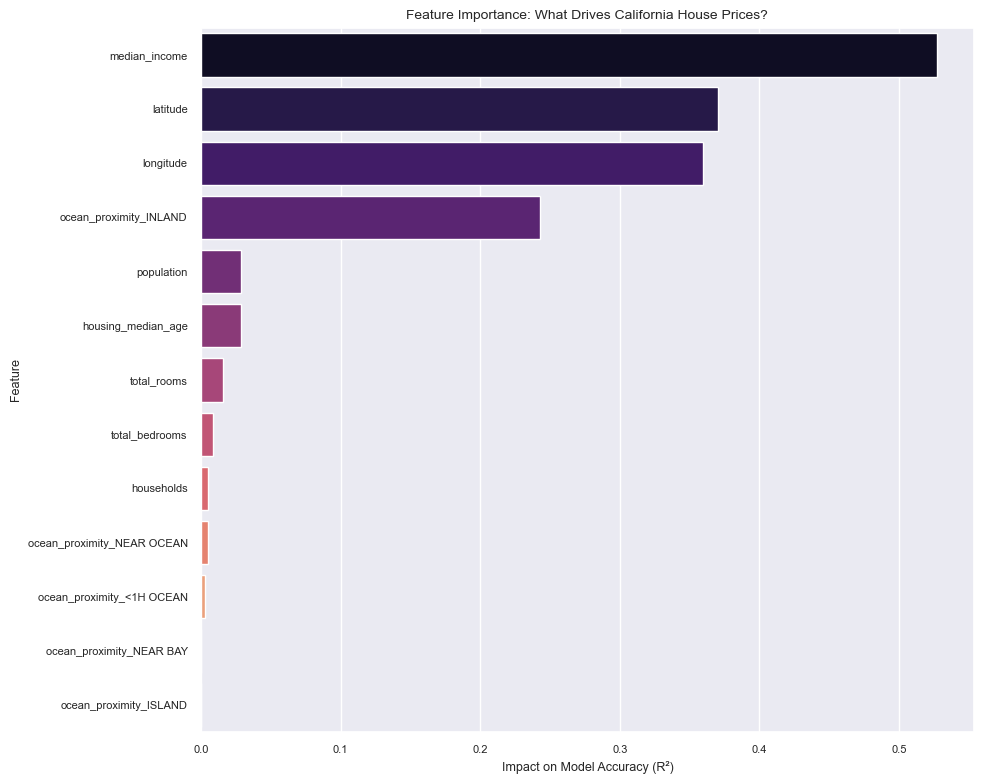

In [42]:
from sklearn.inspection import permutation_importance

# 1. Transform the X_test data FIRST so it matches the model's internal features
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# 2. Get the model out of the pipeline
# Note: 'model' is the name we gave it in the Pipeline steps
final_model = rf_model_pipeline.named_steps['model']

# 3. Calculate importance on the TRANSFORMED data
result = permutation_importance(
    final_model, X_test_transformed, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=None
)

# 4. Build the DataFrame
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Clean up the names (removes 'remainder__' or 'cat__')
importances_df['Feature'] = importances_df['Feature'].str.split('__').str[-1]


# 5. Plot 
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importances_df, 
    hue='Feature',      
    palette='magma', 
    legend=False        
)

plt.title('Feature Importance: What Drives California House Prices?')
plt.xlabel('Impact on Model Accuracy (R²)')
plt.tight_layout()
plt.show()

In [43]:
# Check how many of each category are actually in your Test Set
print(X_test['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     1795
INLAND        1324
NEAR OCEAN     572
NEAR BAY       436
ISLAND           1
Name: count, dtype: int64


**Analysis Note:**
 
 "We observe that ocean_proximity_ISLAND and NEAR BAY show near-zero importance. This is likely due to the extreme scarcity of 'Island' records in the dataset and the model's ability to use geographical coordinates (Latitude/Longitude) to capture the price variance in Bay areas more effectively than the categorical tags. This can be seen in `ocean_proximity` value_counts as shown above."

##  Save the Final Model
To ensure we can use our trained model for future predictions without retraining, 
we serialize the entire pipeline (including preprocessing and target transformation) 
using `joblib`.

In [44]:
import joblib        # joblib is much more efficient at handling large NumPy arrays

# 1. Define the filename
model_filename = "california_housing_model.pkl"

# 2. Save the entire pipeline
joblib.dump(rf_model_pipeline, model_filename)

print(f"✅ Success! model is saved as: {model_filename}")

✅ Success! model is saved as: california_housing_model.pkl


---

#### Conclusion:
**Best Model: HistGradientBoostingRegressor**

The HistGradientBoosting model provided the best balance of accuracy and speed for this dataset.